# Fetch Pick and Place Environment Demo

This notebook demonstrates the MuJoCo Fetch Pick and Place robotic environment.

In [ ]:
import os
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["MUJOCO_GL"] = "egl"
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [3]:
env = gym.make("fetch_pick_and_place/easy")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names() if hasattr(env.action_space, 'get_function_names') else 'Discrete actions'}")
print(f"Observation Space: {env.observation_space}")

Action Space: FuncConditional(['move', 'gripper', 'stop'])
Available actions: ['move', 'gripper', 'stop']
Observation Space: Dict('achieved_goal': Box(-inf, inf, (3,), float64), 'desired_goal': Box(-inf, inf, (3,), float64), 'image': Box(0, 255, (480, 960, 3), uint8), 'observation': Box(-inf, inf, (25,), float64))


## 2. Reset and View Initial State

Observation type: <class 'dict'>
Info: {}


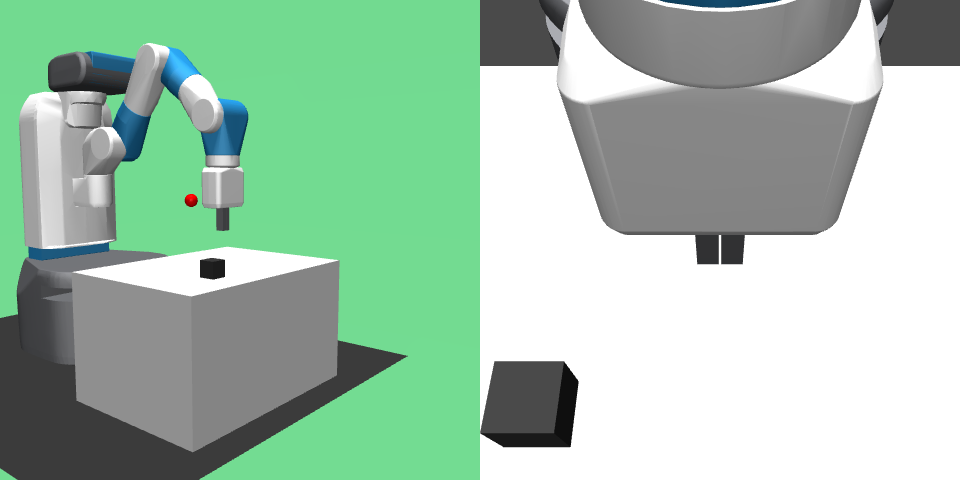


Task: Pick up the cube and place it at the target location

Task Prompt:
You are controlling a robotic arm to pick up a grey cube and place it at the target 3D position. The robot end-effector (gripper) and the cube are visible in the image. The left image is a front view of the robot, and the right image moving camera attached to the gripper. Your goal is to grasp the cube and move it to the red target marker. Each action moves the end-effector by a fixed step size in the specified direction.

Available actions:
1. 'move': Move the end-effector in 3D space. Format: `('move', [x, y, z])` where each element is -1, 0, or 1:
   - x: -1=left, 0=no change, 1=right
   - y: -1=backward, 0=no change, 1=forward
   - z: -1=down, 0=no change, 1=up
2. 'gripper': Control the gripper (sticky behavior). Format: `('gripper', value)` where value is:
   - 0: open the gripper
   - 1: close the gripper
Note: Gripper state is sticky - once set, it continues until changed.
3. 'stop': End the pick and place

In [4]:
obs, info = env.reset()
print(f"Observation type: {type(obs)}")
print(f"Info: {info}")

frame = env.render()
display(Image.fromarray(frame))
print(f"\nTask: Pick up the cube and place it at the target location")
print(f"\nTask Prompt:\n{env.get_prompt() if hasattr(env, 'get_prompt') else 'Standard Fetch Pick and Place task'}")

## 3. Test Random Actions


Step 1: Action = ('stop', J)
Reward: 0.0000, Done: False


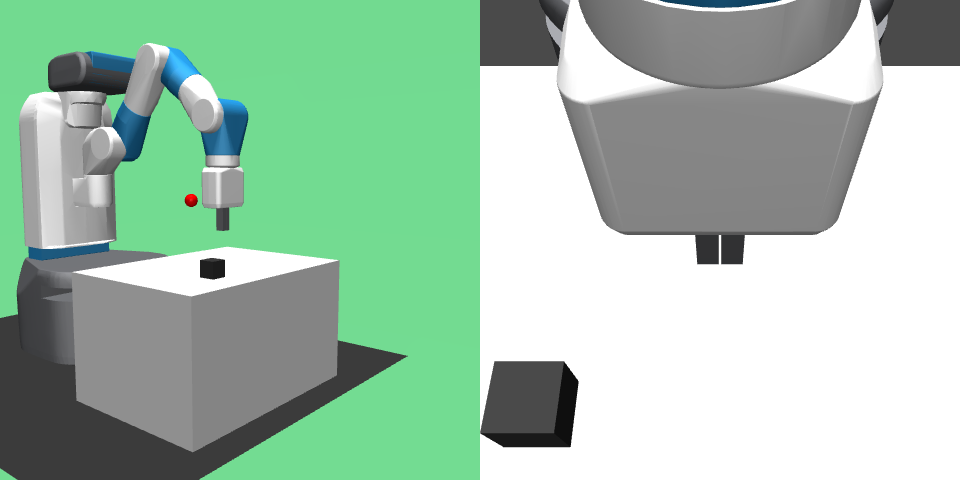


Step 2: Action = ('gripper', 0)
Reward: 0.0000, Done: False

Step 3: Action = ('stop', T)
Reward: 0.0000, Done: False


In [5]:
# Test a few random actions
for i in range(3):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: Action = {action}")
    print(f"Reward: {reward:.4f}, Done: {terminated or truncated}")
    if i == 0:
        frame = env.render()
        display(Image.fromarray(frame))

## 4. Test Solver

Initial configuration:


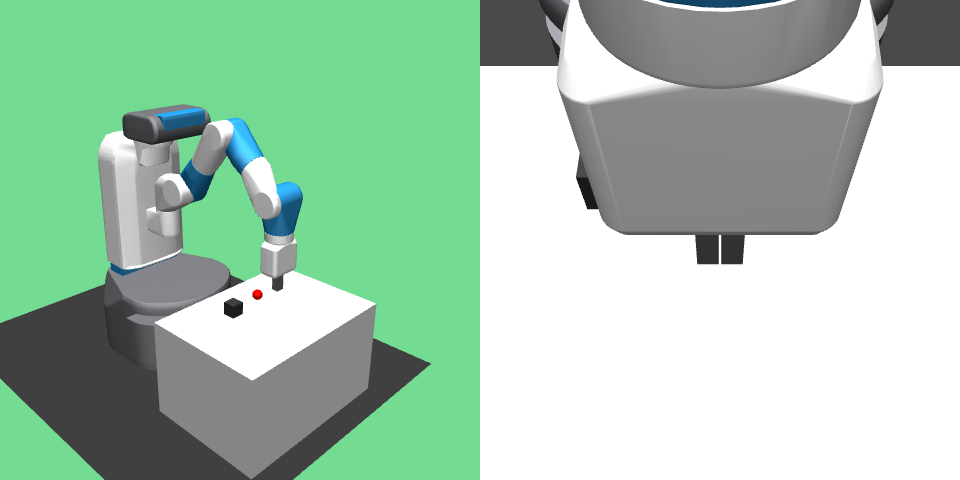


Solver generated 23 actions

/data/users/zwcolin/launch/current/gymnasium/spaces/box.py:423: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")




Step 1: Reward: 0.0000

Step 21: Reward: 0.0000

Step 23: Reward: 1.0000

✓ Task complete! Final reward: 1.0


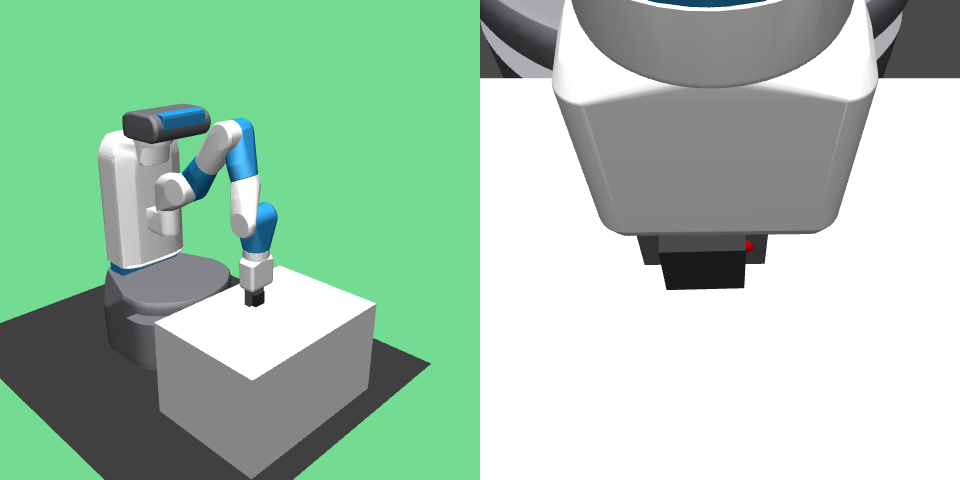

In [6]:
env = gym.make("fetch_pick_and_place/easy", render_mode="rgb_array")
obs, info = env.reset()
print("Initial configuration:")
frame = env.render()
display(Image.fromarray(frame))

# Get solver actions if available
if hasattr(env, 'solve'):
    actions = env.solve()
    print(f"\nSolver generated {len(actions)} actions")
    
    # Execute solver actions
    for i, action in enumerate(actions):
        obs, reward, terminated, truncated, info = env.step(action)
        if i % 20 == 0 or terminated:  # Show every 20th step
            print(f"\nStep {i+1}: Reward: {reward:.4f}")
            if terminated:
                frame = env.render()
                print(f"\n✓ Task complete! Final reward: {reward}")
                display(Image.fromarray(frame))
        if terminated:
            break
else:
    print("Solver not available for this environment")

env.close()